# Plotting jets as images

In [1]:
import time
from coffea import hist
from coffea.analysis_objects import JaggedCandidateArray
import coffea.processor as processor
from awkward import JaggedArray, MaskedArray
import awkward
import numpy as np
import glob as glob
import itertools
import json
import uproot_methods
import copy
from coord_transform import *
import tensorflow as tf
import pandas as pd
import math

np.set_printoptions(threshold=np.inf)

In [2]:
def pseudorapidity(theta):
    return -np.log(np.tan(theta*0.5))

In [3]:
def dataStream(output):
    
    image = output['flippedImages'].value
    labels = output['label'].value
    
    Nconstituents = output['ca_Nconstituents'].value
    
    jetconstEvnum = output['jetconstEvnum'].value
    jetEvnum = output['jetEvnum'].value
    jetconstPt = output['ca_pt_c'].value
    jetconstEta = output['ca_eta_c'].value
    jetconstPhi = output['ca_phi_c'].value
    
    jet0pt = output['ca_jet0pt'].value
    
    log_pt_c = output['ca_log_pt_c'].value
    log_E_c = output['ca_log_E_c'].value
    log_pt_c_jetpt = output['ca_log_pt_c_jetpt'].value
    eta_c = output['ca_eta_c'].value
    dphi_c_jet = output['ca_dphi_c_jet'].value
    deta_c_jet = output['ca_deta_c_jet'].value
    dr_c_jet = output['ca_dr_c_jet'].value
    dr_c_subjet1 = output['ca_dr_c_subjet1'].value
    dr_c_subjet2 = output['ca_dr_c_subjet2'].value
    charge_c = output['ca_charge_c'].value
    isCh_c = output['ca_isCh_c'].value
    isNh_c = output['ca_isNh_c'].value
    isEle_c = output['ca_isEle_c'].value
    isMuon_c = output['ca_isMuon_c'].value
    isPho_c = output['ca_isPho_c'].value
    dxy_c = output['ca_dxy_c'].value
    dz_c = output['ca_dz_c'].value
    pull_c = output['ca_pull_c'].value
    
    
    # add additional event numbers to evnum variables #
    
#     diff = jet0pt.shape[0] - jetEvnum.shape[0]
#     newEvnums = []
#     for d in range(0, diff):
#         newEvnums.append(40000+d)
        
#     jetEvnum = np.append(jetEvnum, newEvnums)
#     jetconstEvnum = np.append(jetconstEvnum, newEvnums)
    
#     jetconstEvnum = np.repeat(jetconstEvnum, Nconstituents.astype(int), axis=0)
    
    print(log_pt_c.shape, 'log_pt_c')
    print(log_E_c.shape, 'log_E_c')
    print(eta_c.shape, 'eta_c')
    print(dphi_c_jet.shape, 'dphi_c_jet')
    print(deta_c_jet.shape, 'deta_c_jet')
    print(dr_c_jet.shape, 'dr_c_jet')
    print(dr_c_subjet1.shape, 'dr_c_subjet1')
    print(dr_c_subjet2.shape, 'dr_c_subjet2')
    print(charge_c.shape, 'charge_c')
    print(dxy_c.shape, 'dxy_c')
    print(dz_c.shape, 'dz_c')
    print(pull_c.shape, 'pull_c')
    print(jetconstEvnum.shape, 'jetconstEvnum')
    print(jet0pt.shape, 'jet0pt')
    print(jetEvnum.shape, 'jetEvnum')
    print(jetconstPt.shape, 'jetconstPt',)
    print(jetconstEta.shape, 'jetconstEta')
    print(jetconstPhi.shape, 'jetconstPhi')
    #print(image.shape, 'image')
    #print(labels.shape, 'labels')
    
    
    
   
    
    
    

    jetFile = '/mnt/data/ml/ShowJetsDataVariables'
    constituentFile = '/mnt/data/ml/Constituent4vecVariables'
    
    np.savez(jetFile, 
             jetImages = image, 
             log_pt_c = log_pt_c,
             log_E_c = log_E_c,
             log_pt_c_jetpt = log_pt_c_jetpt,
             eta_c = eta_c,
             dphi_c_jet = dphi_c_jet,
             deta_c_jet = deta_c_jet,
             dr_c_jet = dr_c_jet,
             dr_c_subjet1 = dr_c_subjet1,
             dr_c_subjet2 = dr_c_subjet2,
             charge_c = charge_c,
             dxy_c = dxy_c,
             dz_c = dz_c,
             pull_c = pull_c,
             labels = labels)

    constituent_labels = np.repeat(labels, 20, axis=0).reshape(jetconstPt.shape[0], 4)
    print(constituent_labels.shape, 'constituent labels')
    
    np.savez(constituentFile,
             jetconstEvnum = jetconstEvnum,
             jetconstPt = jetconstPt,
             jetconstEta = jetconstEta,
             jetconstPhi = jetconstPhi,
             log_pt_c = log_pt_c,
             log_E_c = log_E_c,
             log_pt_c_jetpt = log_pt_c_jetpt,
             eta_c = eta_c,
             dphi_c_jet = dphi_c_jet,
             deta_c_jet = deta_c_jet,
             dr_c_jet = dr_c_jet,
             dr_c_subjet1 = dr_c_subjet1,
             dr_c_subjet2 = dr_c_subjet2,
             charge_c = charge_c,
             isCh_c = isCh_c,
             isNh_c = isNh_c,
             isEle_c = isEle_c,
             isMuon_c = isMuon_c,
             isPho_c = isPho_c,
             dxy_c = dxy_c,
             dz_c = dz_c,
             pull_c = pull_c,
             labels = constituent_labels)


In [4]:
def transform_to_softdrop_axes(jetparticles,Jets):
    
    subjet0leading = (Jets.subjet0_pt > Jets.subjet1_pt)
    centroid1_pt = np.where( subjet0leading, Jets.subjet0_pt, Jets.subjet1_pt  )
    centroid1_eta = np.where( subjet0leading, Jets.subjet0_eta, Jets.subjet1_eta  )
    centroid1_phi = np.where( subjet0leading, Jets.subjet0_phi, Jets.subjet1_phi  )
    centroid1_m = np.where( subjet0leading, Jets.subjet0_m, Jets.subjet1_m  )
    centroid2_pt = np.where( subjet0leading, Jets.subjet1_pt, Jets.subjet0_pt,   )
    centroid2_eta = np.where( subjet0leading, Jets.subjet1_eta, Jets.subjet0_eta  )
    centroid2_phi = np.where( subjet0leading, Jets.subjet1_phi, Jets.subjet0_phi  )
    centroid2_m = np.where( subjet0leading, Jets.subjet1_m, Jets.subjet0_m  )
    pcentroid1 = uproot_methods.TLorentzVectorArray.from_ptetaphim( centroid1_pt, centroid1_eta, centroid1_phi, centroid1_m )
    pcentroid2 = uproot_methods.TLorentzVectorArray.from_ptetaphim( centroid2_pt, centroid2_eta, centroid2_phi, centroid2_m )
    
    #distance between the two centroids
    r0 = pcentroid1.delta_r(pcentroid2)
    
    centroid1 = uproot_methods.TVector3Array.from_cartesian(pcentroid1.x, pcentroid1.y, pcentroid1.z)
    centroid2 = uproot_methods.TVector3Array.from_cartesian(pcentroid2.x, pcentroid2.y, pcentroid2.z)
    particle_p3s = uproot_methods.TVector3Array.from_cartesian(jetparticles.p4.x, jetparticles.p4.y, jetparticles.p4.z)
    
    # Rotate coordinate system so "centroid1" is along the x axis
    rot1_axis, rot1_angle = coord_rotation( centroid1, uproot_methods.TVector3(1,0,0) )    
    centroid1 = centroid1.rotate_axis(rot1_axis, rot1_angle)
    centroid2 = centroid2.rotate_axis(rot1_axis, rot1_angle)
    particle_p3s = particle_p3s.rotate_axis(rot1_axis, rot1_angle)

    # Rotate about the z axis so that centroid2 is pointing down
    rot2_angle = -np.arctan2( centroid2.z, centroid2.y )
    centroid2 = centroid2.rotatex(rot2_angle)
    particle_p3s = particle_p3s.rotatex(rot2_angle)
    
    # Scale the image so that centroid2 is at (0,1,0)
    deta = np.divide(pseudorapidity(particle_p3s.theta),r0)
    dphi = np.divide(particle_p3s.phi,r0)
        
    return deta,dphi,centroid1,centroid2

In [5]:
def delta_pull(self, other):
    return (self - other + math.pi) % (2*math.pi) - math.pi

In [6]:
# Look at ProcessorABC to see the expected methods and what they are supposed to do
class JetImageProcessor(processor.ProcessorABC):
    def __init__(self):
        self.eta_bins = 16
        self.phi_bins = 16
        dataset_axis = hist.Cat("dataset", "Primary dataset")
        event_axis = hist.Bin("event", "Event number", 10000, 0, 10000 )
        pdgid_axis = hist.Bin("pdgid", r"PDG ID", 10000, -5000, 5000)
        eta_axis = hist.Bin("eta", r"$\eta$", 32, -5, 5)
        phi_axis = hist.Bin("phi", r"$\phi$", 32, -np.pi, np.pi)
        deta_axis = hist.Bin("deta", r"$\Delta\phi$", 1000, -1, 1)
        dphi_axis = hist.Bin("dphi", r"$\Delta\phi$", 1000, -1, 1)
        image_dphi = hist.Bin("image_dphi", r"$Q_1$", self.phi_bins, -2, 2) #yaxis
        image_deta = hist.Bin("image_deta", r"$Q_2$", self.eta_bins, -2, 2) #xaxis
        pt_axis = hist.Bin("pt", r"$p_{T}$ [GeV]", 1000, 0, 5000)
        logpt_axis = hist.Bin("logpt", r"log($p_{T}$) [GeV]", 1000, 0, 1)
        logpt_frac_axis = hist.Bin("logpt_frac", r"log($p_{T}$) / Jet $p_T$ ", 1000, 0, 0.05)
        logE_axis = hist.Bin("logE", r"log($E$) [GeV]", 1000, 0, 1)
        m_axis = hist.Bin("m", r"$p_{T}$ [GeV]", 200, 0, 500)
        dr_axis = hist.Bin("dr", r"$\Delta r$", 80, 0, 0.8)
        dr_c_jet_axis = hist.Bin("dr_c_jet", r"$\Delta r$", 80, 0, 0.8)
        tau_axis = hist.Bin("tau", r"$\tau$", 100, 0, 1.0)
        particle_axis = hist.Cat("particle", "Particle Type") # hist.Cat -- list of categories
        binary_axis = hist.Bin("binary", "Is Particle", 2, -0.5, 1.5)
        charge_axis = hist.Bin("charge", "Charge", 3, -1.5, 1.5)
        mult_axis = hist.Bin("mult", "Multiplicity", 50, 0, 50)
        pullAngle_axis = hist.Bin("pullAngle", "Jet Pull Angle", 100, -5, 5)
        pull_axis = hist.Bin("pull", "Jet Pull", 100, 0, 0.1)
        vertex_axis = hist.Bin("vertex", "Vertex (mm)", 100, -10, 10)

        
        self._accumulator = processor.dict_accumulator({
            
            'h_pt':hist.Hist("Counts", dataset_axis, pt_axis),
            'h_eta':hist.Hist("Counts", dataset_axis, eta_axis),
            'h_image':hist.Hist(r"$p_{T}$", dataset_axis, event_axis, image_dphi, image_deta),
            'h_jetPullAngle':hist.Hist("Counts", dataset_axis, pullAngle_axis),
            'h_jetpt':hist.Hist("Counts", dataset_axis, pt_axis),    
            
            # deepAK8 variables#
            'h_log_pt_c':hist.Hist("Counts", dataset_axis, logpt_axis),
            'h_log_E_c':hist.Hist("Counts", dataset_axis, logE_axis),
            'h_log_pt_c_jetpt':hist.Hist("Counts", dataset_axis, logpt_frac_axis),
            'h_eta_c':hist.Hist("Counts", dataset_axis, eta_axis),
            'h_dphi_c_jet':hist.Hist("Counts", dataset_axis, dphi_axis),
            'h_deta_c_jet':hist.Hist("Counts", dataset_axis, deta_axis),
            'h_dr_c_jet':hist.Hist("Counts", dataset_axis, dr_c_jet_axis),
            'h_dr_c_subjet1':hist.Hist("Counts", dataset_axis, dr_c_jet_axis),
            'h_dr_c_subjet2':hist.Hist("Counts", dataset_axis, dr_c_jet_axis),
            'h_particle':hist.Hist("Counts", dataset_axis, binary_axis, particle_axis),
            'h_color_c':hist.Hist("Counts", dataset_axis, binary_axis),
            'h_charge_c':hist.Hist("Counts", dataset_axis, charge_axis),
            'h_dxy_c':hist.Hist("Counts", dataset_axis, vertex_axis),
            'h_dz_c':hist.Hist("Counts", dataset_axis, vertex_axis),
     
            
            
            # column accumulators #
            'label': processor.column_accumulator(np.zeros(shape=(0,4))),
            'flippedImages': processor.column_accumulator(np.zeros(shape=(0,16,16))),
            'ca_Nconstituents': processor.column_accumulator(np.zeros(shape=(0))),
            'jetconstEvnum': processor.column_accumulator(np.zeros(shape=(0))),
            'jetEvnum': processor.column_accumulator(np.zeros(shape=(0))),
            
            'ca_jet0pt': processor.column_accumulator(np.zeros(shape=(0))),
            
            'ca_pt_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_eta_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_phi_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_E_c': processor.column_accumulator(np.zeros(shape=(0))),
            
            'ca_log_pt_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_log_E_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_log_pt_c_jetpt': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_eta_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dphi_c_jet': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_deta_c_jet': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dr_c_jet': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dr_c_subjet1': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dr_c_subjet2': processor.column_accumulator(np.zeros(shape=(0))),
            #'ca_particle': processor.column_accumulator(np.zeros(shape=(0))),
            #'ca_color_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_charge_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_isCh_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_isNh_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_isEle_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_isMuon_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_isPho_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dxy_c': processor.column_accumulator(np.zeros(shape=(0))),
            'ca_dz_c': processor.column_accumulator(np.zeros(shape=(0))),
            
            'ca_pull_c': processor.column_accumulator(np.zeros(shape=(0))),
            
        })
    
    @property
    def accumulator(self):
        return self._accumulator
    
    def process(self, df):
        
        output = self.accumulator.identity()

        dataset = df['dataset']
        evnum = df['eventNum']
        
        Jets = JaggedCandidateArray.candidatesfromcounts(
            df['nJet'],
            pt=df['jet_pt'],
            eta=df['jet_eta'],
            phi=df['jet_phi'],
            mass=df['jet_m'],
            msd=df['jet_msd'],
            nsubjet=df['jet_nsubjet'],
            subjet0_pt=df['jet_subjet0_pt'],
            subjet0_eta=df['jet_subjet0_eta'],
            subjet0_phi=df['jet_subjet0_phi'],
            subjet0_m=df['jet_subjet0_m'],
            subjet1_pt=df['jet_subjet1_pt'],
            subjet1_eta=df['jet_subjet1_eta'],
            subjet1_phi=df['jet_subjet1_phi'],
            subjet1_m=df['jet_subjet1_m'],
            tau1=df['jet_tau1'],
            tau2=df['jet_tau2'],
            tau3=df['jet_tau3'],
            tau4=df['jet_tau4'],
            vyy=df['gen_vyy'],
            vzz=df['gen_vzz'],
#             ic=df['jet_ic'],
            nc=df['jet_nc']
            )        
        constituents = JaggedCandidateArray.candidatesfromcounts(
            df['nConstituent'],
            pt=df['constituent_pt'],
            eta=df['constituent_eta'],
            phi=df['constituent_phi'],
            mass=df['constituent_m'],
            pdgid=df['constituent_id'],
            status=df['constituent_status'],
            jetndx=df['constituent_jetndx'], # constituents belonging to the leading jet
            subjetndx=df['constituent_subjetndx'],
            col=df['constituent_col'],
            vxx=df['constituent_vxx'],
            vyy=df['constituent_vyy'],
            vzz=df['constituent_vzz'],
            )
        
        deta,dphi,centroid1,centroid2= transform_to_softdrop_axes(constituents, Jets[:,0])        
        constituents.add_attributes( deta=deta )
        constituents.add_attributes( dphi=dphi )
        
        constituents = constituents[constituents.status==91] # only final state particles in the jet
        constituents = constituents[constituents.pt > 1]
        
        # constituent cuts 
        matchedJet = constituents.jetndx > -1 # constituents that have an index matched to AK8 jet
        matchedJetpt200 = Jets[constituents.jetndx[matchedJet]].p4.pt > 200
        constituents = constituents[matchedJet][matchedJetpt200]
    
        
        
        Jets = Jets[ Jets.nsubjet >= 2 ]
        
        Jets = Jets[Jets.pt > 200]
        oneJet = Jets.counts >= 1
        Jets = Jets[oneJet]
        constituents = constituents[oneJet]
        
        
        dr = Jets[:,0].p4.delta_r(constituents.p4)
        jetconstituents=constituents[constituents.jetndx == 0]
        
        
#         print('Shape1')
#         print(jetconstituents.shape)
#         print(Jets.shape)
#         print()

        validImages = np.zeros(int(np.max(evnum)+1), dtype=bool)
        evnum = evnum[oneJet]
        validImages[evnum] = True
            
        deta = jetconstituents.deta
        dphi = jetconstituents.dphi
        
        # Get the leading 20 constituents in each event for
        # output to a npz file for deepak8 like architechtures. 
        truncated_constituents = jetconstituents[jetconstituents.pt.argsort()][:,:20]
        #print(truncated_constituents[truncated_constituents.counts < 20].counts)

        # Make a Jagged Array of event numbers with the correct offsets
        jaggedshape = JaggedArray.fromoffsets( jetconstituents.offsets, np.ones(deta.flatten().shape[0]))
        eventReshaped = jaggedshape * evnum
        
#         print( jetconstituents.pt.flatten().shape, 'jetconstituents')
#         print(eventReshaped.flatten().shape, 'eventReshaped')
#         print(jaggedshape.shape, 'jaggedshape')
#         print(evnum.flatten().shape, 'evnum')
#         print(eventReshaped[:,:1].flatten().shape, 'eventReshaped')
#         print(Jets.counts.shape, 'jet shape')
        
        
        # Performing parity flip so that sum(right) is higher than sum(left) for each image
        eventbins = np.arange(len(validImages)+1)
        xbins= np.linspace(-2,2,num=self.eta_bins+1)
        ybins= np.linspace(-2,2,num=self.phi_bins+1)
        
        # For the images, normalize each constituent to the jet pt
        # to remove any pt dependence
        const_pts = jetconstituents.pt
        normed_pts = const_pts / Jets[:,0].p4.pt
        
        #print('normed_pts = ', normed_pts)
    
        H_images = np.histogramdd((eventReshaped.flatten(),dphi.flatten(),deta.flatten()),
                                  bins=(eventbins ,ybins, xbins), weights = normed_pts.flatten())[0]
        H_images = H_images[validImages]
        mask = (np.sum(H_images[:,:,:int(self.eta_bins/2)], axis = (1,2)) < np.sum(H_images[:,:,int(self.eta_bins/2):], axis = (1,2)))
        sign = np.where(mask, 1, -1)
        deta = (sign*deta)
        H_images_new = np.histogramdd((eventReshaped.flatten(),dphi.flatten(),deta.flatten()),
                                      bins=(eventbins ,ybins, xbins), weights = normed_pts.flatten())[0]


            
    

            
#         # Adding the ch, nh, e, mu, gamma multiplicity information   
#         isEle = (abs(jetconstituents.pdgid) == 11)
#         isMuon = (abs(jetconstituents.pdgid) == 13)
#         isPho = (abs(jetconstituents.pdgid) == 22)
#         isCh = (abs(jetconstituents.pdgid) == 2212) | (abs(jetconstituents.pdgid) == 211) | (abs(jetconstituents.pdgid) == 321)
#         isNh = (abs(jetconstituents.pdgid) == 2112) | (abs(jetconstituents.pdgid) == 130)
        
#         ele = np.char.multiply('e',pd.DataFrame((abs(truncated_constituents.pdgid) == 11)).fillna(False).values.astype(int))
#         muon = np.char.multiply('mu',pd.DataFrame((abs(truncated_constituents.pdgid) == 13)).fillna(False).values.astype(int))
#         gamma = np.char.multiply('gamma',pd.DataFrame((abs(truncated_constituents.pdgid) == 22)).fillna(False).values.astype(int))
#         ch = np.char.multiply('ch',pd.DataFrame((abs(truncated_constituents.pdgid) == 2212) | (abs(truncated_constituents.pdgid) == 211) | (abs(truncated_constituents.pdgid) == 321)).fillna(False).values.astype(int))
#         nh = np.char.multiply('nh',pd.DataFrame((abs(truncated_constituents.pdgid) == 2112) | (abs(truncated_constituents.pdgid) == 130)).fillna(False).values.astype(int))
#         particleType = np.char.add((np.char.add((np.char.add(ele,gamma)),(np.char.add(ch,nh)))),muon)

        
        
        
        # Adding n-subjettiness information
        tau1 = Jets.tau1[:,0].flatten()
        tau2 = Jets.tau2[:,0].flatten()
        tau3 = Jets.tau3[:,0].flatten()
        tau4 = Jets.tau4[:,0].flatten()

        tau21 = np.where( tau1 > 0, tau2/tau1, 0)
        tau31 = np.where( tau1 > 0, tau3/tau1, 0)
        tau32 = np.where( tau2 > 0, tau3/tau2, 0)
        
        # Adding Jet Pull information
        
        # only subjet information from now on so cutting on 20 consituents
        
        Jets = Jets[Jets.counts >= 1]
        Nconst20 = truncated_constituents.counts > 19
        truncated_constituents = truncated_constituents[Nconst20]
        Jets = Jets[Nconst20]
        
        
        #print('Jets', Jets.shape)
        SubJet0 = uproot_methods.TLorentzVectorArray.from_ptetaphim( Jets[:,0].subjet0_pt, Jets[:,0].subjet0_eta, Jets[:,0].subjet0_phi, Jets[:,0].subjet0_m )
        SubJet1 = uproot_methods.TLorentzVectorArray.from_ptetaphim( Jets[:,0].subjet1_pt, Jets[:,0].subjet1_eta, Jets[:,0].subjet1_phi, Jets[:,0].subjet1_m )

        SubJet0_constituents = truncated_constituents[(truncated_constituents.jetndx == 0) & (truncated_constituents.subjetndx == 0)]
        SubJet1_constituents = truncated_constituents[(truncated_constituents.jetndx == 0) & (truncated_constituents.subjetndx == 1)]

        # Calculating jet pull
        constituent_pt = SubJet0_constituents.pt
        constituent_y = SubJet0_constituents.p4.rapidity
        constituent_phi = SubJet0_constituents.p4.phi
        
        pull_dphi = SubJet1.delta_phi(SubJet0)
        pull_dy = SubJet1.rapidity - SubJet0.rapidity
        pull_jet_angle = np.arctan2(pull_dphi, pull_dy)

        #pull_i_r = SubJet0_constituents.p4.delta_r(SubJet0)
        #pull_i_r = np.sqrt(np.power(SubJet0_constituents.p4.rapidity,2) + np.power(SubJet0_constituents.p4.phi,2) )
        pull_i_r = np.sqrt((SubJet0_constituents.p4.rapidity - SubJet0.rapidity)**2 + SubJet0_constituents.p4.delta_phi(SubJet0)**2)
        pull_i_dphi = SubJet0_constituents.p4.delta_phi(SubJet0)
        pull_i_dy = SubJet0_constituents.p4.rapidity - SubJet0.rapidity
        
        # Calculate phi and y components of pull
        valtemp = np.divide( np.multiply(constituent_pt, pull_i_r), Jets[:,0].p4.pt )
        pull_tosum_phi = np.multiply(valtemp, pull_i_dphi)
        pull_tosum_y = np.multiply(valtemp, pull_i_dy)
        
        pull_sum_phi = pull_tosum_phi.sum()
        pull_sum_y = pull_tosum_y.sum()
        pull_mag = np.sqrt(np.power(pull_sum_phi,2) + np.power(pull_sum_y,2))
        
        # Calculate pull angle in polar coordinates
        pull_angle_calc = np.arctan2(pull_sum_phi, pull_sum_y)
        pull_angle = delta_pull(pull_angle_calc, pull_jet_angle)
        
        
        ## Creating DeepAK8 Variables ##
        
        #matchedJet = constituents.jetndx > -1
        #matchedJetpt200 = Jets[matchedJet].p4.pt > 200
        
        '''
        PDG IDs of jet constituents:
        11, 12, 13, 14, 15, 16, 22, 130, 211, 321, 2112, 2212
        '''
        
#         # Adding the ch, nh, e, mu, gamma multiplicity information   
#         isEle = (abs(jetconstituents.pdgid) == 11)
#         isMuon = (abs(jetconstituents.pdgid) == 13)
#         isPho = (abs(jetconstituents.pdgid) == 22)
#         isCh = (abs(jetconstituents.pdgid) == 2212) | (abs(jetconstituents.pdgid) == 211) | (abs(jetconstituents.pdgid) == 321)
#         isNh = (abs(jetconstituents.pdgid) == 2112) | (abs(jetconstituents.pdgid) == 130)
        
#         #print(type(isEle))
#         isNegOne = (jetconstituents.pdgid == 11) | (jetconstituents.pdgid == 13) | (jetconstituents.pdgid == 15) | \
#         (jetconstituents.pdgid == -2212) | (jetconstituents.pdgid == -211) | (jetconstituents.pdgid == -321)
        
        
#         isPosOne = (jetconstituents.pdgid == -11) | (jetconstituents.pdgid == -13) | (jetconstituents.pdgid == -15) | \
#         (jetconstituents.pdgid == 2212) | (jetconstituents.pdgid == 211) | (jetconstituents.pdgid == 321)
        
#         isZero = (jetconstituents.pdgid == 22) | (jetconstituents.pdgid == -22) | (jetconstituents.pdgid == 2112) | \
#         (jetconstituents.pdgid == -2112) | (jetconstituents.pdgid == 130) | (jetconstituents.pdgid == -130) | \
#         (jetconstituents.pdgid == 12) | (jetconstituents.pdgid == 14) | (jetconstituents.pdgid == 16) | \
#         (jetconstituents.pdgid == -12) | (jetconstituents.pdgid == -14) | (jetconstituents.pdgid == -16)
        
#         charge = JaggedArray.ones_like(isNegOne)*100
#         charge[isNegOne] = -1
#         charge[isPosOne] = 1
#         charge[isZero] = 0
        
        
#         color_c = jetconstituents.col
    

        
#         jet0 = Jets[:,0]
#         pt_c = jetconstituents.pt
#         E_c = jetconstituents.p4.energy
#         eta_c = jetconstituents.eta
#         jetpt_matched = jet0.p4.pt
        
#         log_pt_c = np.log(pt_c)
#         log_E_c = np.log(E_c)
#         abs_eta_c = np.abs(eta_c)
        
#         dphi_c_jet = jetconstituents.p4.delta_phi(jet0.p4)
#         deta_c_jet = jetconstituents.eta - jet0.p4.eta
        
#         dr_c_jet = jetconstituents.p4.delta_r(jet0.p4)
#         dr_c_subjet1 = jetconstituents.p4.delta_r(SubJet0)
#         dr_c_subjet2 = jetconstituents.p4.delta_r(SubJet1)
        
#         dz = jetconstituents.vzz
#         dxy = np.sqrt(np.power(jetconstituents.vxx, 2) + np.power(jetconstituents.vxx, 2) )
        

 # Adding the ch, nh, e, mu, gamma multiplicity information   
        isEle = (abs(truncated_constituents.pdgid) == 11)
        isMuon = (abs(truncated_constituents.pdgid) == 13)
        isPho = (abs(truncated_constituents.pdgid) == 22)
        isCh = (abs(truncated_constituents.pdgid) == 2212) | (abs(truncated_constituents.pdgid) == 211) | (abs(truncated_constituents.pdgid) == 321)
        isNh = (abs(truncated_constituents.pdgid) == 2112) | (abs(truncated_constituents.pdgid) == 130)
        
        #print(type(isEle))
        isNegOne = (truncated_constituents.pdgid == 11) | (truncated_constituents.pdgid == 13) | (truncated_constituents.pdgid == 15) | \
        (truncated_constituents.pdgid == -2212) | (truncated_constituents.pdgid == -211) | (truncated_constituents.pdgid == -321)
        
        
        isPosOne = (truncated_constituents.pdgid == -11) | (truncated_constituents.pdgid == -13) | (truncated_constituents.pdgid == -15) | \
        (truncated_constituents.pdgid == 2212) | (truncated_constituents.pdgid == 211) | (truncated_constituents.pdgid == 321)
        
        isZero = (truncated_constituents.pdgid == 22) | (truncated_constituents.pdgid == -22) | (truncated_constituents.pdgid == 2112) | \
        (truncated_constituents.pdgid == -2112) | (truncated_constituents.pdgid == 130) | (truncated_constituents.pdgid == -130) | \
        (truncated_constituents.pdgid == 12) | (truncated_constituents.pdgid == 14) | (truncated_constituents.pdgid == 16) | \
        (truncated_constituents.pdgid == -12) | (truncated_constituents.pdgid == -14) | (truncated_constituents.pdgid == -16)
        
        charge = JaggedArray.ones_like(isNegOne)*100
        charge[isNegOne] = -1
        charge[isPosOne] = 1
        charge[isZero] = 0
        
        charge = charge.pad(20).fillna(999.0)
        
        color_c = truncated_constituents.col
        
    

        
        jet0 = Jets[:,0]
        

        
        # 4-vector information #
        pt_c = truncated_constituents.pt.pad(20).fillna(999.)
        eta_c = truncated_constituents.eta.pad(20).fillna(999.)
        phi_c = truncated_constituents.phi.pad(20).fillna(999.)
        E_c = truncated_constituents.p4.energy.pad(20).fillna(999.)
        
        jetpt_matched = jet0.p4.pt

        
        log_pt_c = np.log(pt_c).pad(20).fillna(999.)
        log_E_c = np.log(E_c).pad(20).fillna(999.)
        abs_eta_c = np.abs(eta_c).pad(20).fillna(999.)
        
        dphi_c_jet = truncated_constituents.p4.delta_phi(jet0.p4).pad(20).fillna(999.)
        deta_c_jet = (truncated_constituents.eta - jet0.p4.eta).pad(20).fillna(999.)
        
        dr_c_jet = truncated_constituents.p4.delta_r(jet0.p4).pad(20).fillna(999.)
        dr_c_subjet1 = truncated_constituents.p4.delta_r(SubJet0).pad(20).fillna(999.)
        dr_c_subjet2 = truncated_constituents.p4.delta_r(SubJet1).pad(20).fillna(999.)
        
        dz = truncated_constituents.vzz.pad(20).fillna(999.0)
        dxy = np.sqrt(np.power(truncated_constituents.vxx, 2) + np.power(truncated_constituents.vxx, 2) ).pad(20).fillna(999.0)
        
        Nconstituents = truncated_constituents.counts

        
        log_pt_c_jetpt = np.divide(log_pt_c, jetpt_matched).pad(20).fillna(999.0)
        
        labels = np.zeros([len(truncated_constituents.pt.pad(20)),4])
        if ("Zprime1TeV" in dataset):
            labels[:,1]=1
        elif ("Zprime2TeV" in dataset):
            labels[:,2]=1
        elif ("Zprime3TeV" in dataset):
            labels[:,3]=1
        else:
            labels[:,0]=1
            
        #mask_labels_row = (Jets.counts >= 1) & (Jets[:,0].nsubjet >= 2) & (Jets[:,0].p4.pt > 200)
        mask_labels_row = (Jets.counts >= 1) & (Jets.nsubjet >= 2) & (Jets.pt > 200)
        mask_labels_row = mask_labels_row.any()
        
        mask_labels = np.vstack((mask_labels_row, mask_labels_row, mask_labels_row, mask_labels_row)).T
        labels = labels[mask_labels].reshape(mask_labels.shape[0], 4)
     
        output['h_log_pt_c'].fill(dataset=dataset, 
                                  logpt=log_pt_c.flatten())
        output['h_log_E_c'].fill(dataset=dataset, 
                                  logE=log_E_c.flatten())
        output['h_log_pt_c_jetpt'].fill(dataset=dataset, 
                                  logpt_frac=log_pt_c_jetpt.flatten())
        output['h_eta_c'].fill(dataset=dataset, 
                             eta=abs_eta_c.flatten())
        output['h_dphi_c_jet'].fill(dataset=dataset, 
                             dphi=dphi_c_jet.flatten())
        output['h_deta_c_jet'].fill(dataset=dataset, 
                             deta=deta_c_jet.flatten())
        output['h_dr_c_jet'].fill(dataset=dataset, 
                             dr_c_jet=dr_c_jet.flatten())
        output['h_dr_c_subjet1'].fill(dataset=dataset, 
                             dr_c_jet=dr_c_subjet1.flatten())
        output['h_dr_c_subjet2'].fill(dataset=dataset, 
                             dr_c_jet=dr_c_subjet2.flatten())
        
        output['h_particle'].fill(dataset=dataset, 
                             binary=isEle.flatten(),
                             particle='Electron')
        output['h_particle'].fill(dataset=dataset, 
                             binary=isMuon.flatten(),
                             particle='Muon')
        output['h_particle'].fill(dataset=dataset, 
                             binary=isPho.flatten(),
                             particle='Photon')
        output['h_particle'].fill(dataset=dataset, 
                             binary=isCh.flatten(),
                             particle='Charged Hadron')
        output['h_particle'].fill(dataset=dataset, 
                             binary=isNh.flatten(),
                             particle='Neutral Hadron')
        output['h_charge_c'].fill(dataset=dataset, 
                             charge=charge.flatten())
        output['h_color_c'].fill(dataset=dataset, 
                             binary=color_c.flatten())
        output['h_dxy_c'].fill(dataset=dataset, 
                             vertex=dxy.flatten())
        output['h_dz_c'].fill(dataset=dataset, 
                             vertex=dz.flatten())
        output['h_dz_c'].fill(dataset=dataset, 
                             vertex=dz.flatten())
        output['h_jetpt'].fill(dataset=dataset, 
                             pt=jetpt_matched.flatten())
        
        
        
        jetEvnum = eventReshaped[:,:1]
        
        # fill column accumulators #
        
        output['label'] += processor.column_accumulator(labels)
        output['flippedImages'] += processor.column_accumulator(H_images_new[validImages])
        output['ca_Nconstituents'] += processor.column_accumulator(Nconstituents.flatten())
       # output['jetconstEvnum'] += processor.column_accumulator(np.repeat(jetEvnum.flatten(), 20, axis=0))
        output['jetconstEvnum'] += processor.column_accumulator(jetEvnum.flatten())
        output['jetEvnum'] += processor.column_accumulator(jetEvnum.flatten())
        
        
        output['ca_jet0pt'] += processor.column_accumulator(jetpt_matched.flatten())
        
        output['ca_pt_c'] += processor.column_accumulator(pt_c.flatten())
        output['ca_eta_c'] += processor.column_accumulator(eta_c.flatten())
        output['ca_phi_c'] += processor.column_accumulator(phi_c.flatten())
        output['ca_E_c'] += processor.column_accumulator(E_c.flatten())
        
        output['ca_log_pt_c'] += processor.column_accumulator(log_pt_c.flatten())        
        output['ca_log_E_c'] += processor.column_accumulator(log_E_c.flatten())
        output['ca_log_pt_c_jetpt'] += processor.column_accumulator(log_pt_c_jetpt.flatten())
        output['ca_dphi_c_jet'] += processor.column_accumulator(dphi_c_jet.flatten())
        output['ca_deta_c_jet'] += processor.column_accumulator(deta_c_jet.flatten())
        output['ca_dr_c_jet'] += processor.column_accumulator(dr_c_jet.flatten())
        output['ca_dr_c_subjet1'] += processor.column_accumulator(dr_c_subjet1.flatten())
        output['ca_dr_c_subjet2'] += processor.column_accumulator(dr_c_subjet2.flatten())
        #output['ca_particle'] += processor.column_accumulator(particle.flatten())
        #output['ca_color_c'] += processor.column_accumulator(color_c.flatten())
        output['ca_charge_c'] += processor.column_accumulator(charge.flatten())
        output['ca_isCh_c'] += processor.column_accumulator(isCh.flatten())
        output['ca_isNh_c'] += processor.column_accumulator(isNh.flatten())
        output['ca_isEle_c'] += processor.column_accumulator(isEle.flatten())
        output['ca_isMuon_c'] += processor.column_accumulator(isMuon.flatten())
        output['ca_isPho_c'] += processor.column_accumulator(isPho.flatten())
        output['ca_dxy_c'] += processor.column_accumulator(dxy.flatten())
        output['ca_dz_c'] += processor.column_accumulator(dz.flatten())
        output['ca_pull_c'] += processor.column_accumulator(np.repeat(pull_angle.flatten(), 20, axis=0))
        
        
        
        
        

        
        output['h_pt'].fill(dataset=dataset, 
                            pt=Jets.pt[:,0].flatten())   
        output['h_eta'].fill(dataset=dataset, 
                             eta=Jets.eta[:,0].flatten())
        output['h_image'].fill(dataset=dataset, 
                               event=eventReshaped.flatten(), 
                               image_deta=deta.flatten(), 
                               image_dphi=dphi.flatten(), 
                               weight=normed_pts.flatten())
        output['h_jetPullAngle'].fill(dataset=dataset, 
                                      pullAngle=pull_angle.flatten())

        
        return output

    def postprocess(self, accumulator):
        return accumulator

In [7]:
fileset={
     'Zprime1TeV':['/mnt/data/ml/gravkk_zz_1TeV_addindices.root'],
     'Zprime2TeV':['/mnt/data/ml/gravkk_zz_2TeV_addindices.root'],
     'Zprime3TeV':['/mnt/data/ml/gravkk_zz_3TeV_addindices.root'],
     'QCD':['/mnt/data/ml/qcd_flat15to7000_addindices.root']
}
tstart = time.time() 
output = processor.run_uproot_job(fileset,
                                  treename='T',
                                  processor_instance=JetImageProcessor(),
                                  executor=processor.futures_executor,
                                  executor_args={'workers':8, 'flatten': True},
                                  chunksize=5000, maxchunks=20)
elapsed = time.time() - tstart
# print(output)

In [8]:
parameters = list(output)
print(parameters)
dataStream(output)

['h_pt', 'h_eta', 'h_image', 'h_jetPullAngle', 'h_jetpt', 'h_log_pt_c', 'h_log_E_c', 'h_log_pt_c_jetpt', 'h_eta_c', 'h_dphi_c_jet', 'h_deta_c_jet', 'h_dr_c_jet', 'h_dr_c_subjet1', 'h_dr_c_subjet2', 'h_particle', 'h_color_c', 'h_charge_c', 'h_dxy_c', 'h_dz_c', 'label', 'flippedImages', 'ca_Nconstituents', 'jetconstEvnum', 'jetEvnum', 'ca_jet0pt', 'ca_pt_c', 'ca_eta_c', 'ca_phi_c', 'ca_E_c', 'ca_log_pt_c', 'ca_log_E_c', 'ca_log_pt_c_jetpt', 'ca_dphi_c_jet', 'ca_deta_c_jet', 'ca_dr_c_jet', 'ca_dr_c_subjet1', 'ca_dr_c_subjet2', 'ca_charge_c', 'ca_isCh_c', 'ca_isNh_c', 'ca_isEle_c', 'ca_isMuon_c', 'ca_isPho_c', 'ca_dxy_c', 'ca_dz_c', 'ca_pull_c']
(6060660,) log_pt_c
(6060660,) log_E_c
(6060660,) eta_c
(6060660,) dphi_c_jet
(6060660,) deta_c_jet
(6060660,) dr_c_jet
(6060660,) dr_c_subjet1
(6060660,) dr_c_subjet2
(6060660,) charge_c
(6060660,) dxy_c
(6060660,) dz_c
(6060660,) pull_c
(355544,) jetconstEvnum
(303033,) jet0pt
(355544,) jetEvnum
(6060660,) jetconstPt
(6060660,) jetconstEta
(60606

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [10]:
plt.rcParams['figure.dpi'] = 90

In [11]:
# fig, ax = hist.plotgrid(output['h_pt'], overlay="dataset", stack=False, density=True
#                                  )
# for iax in ax.flatten():
#     iax.autoscale(axis='y')
#     iax.set_title(r'Jet $p_T$')


# fig.show()
# fig.savefig("Variables/jetpt.png")

In [12]:
# fig, ax = hist.plotgrid(output['h_eta'], overlay="dataset", stack=False, density=True
#                                  )
# for iax in ax.flatten():
#     iax.autoscale(axis='y')
#     iax.set_title(r'Jet $\eta$')


# fig.show()
# fig.savefig("Variables/jetpt.png")

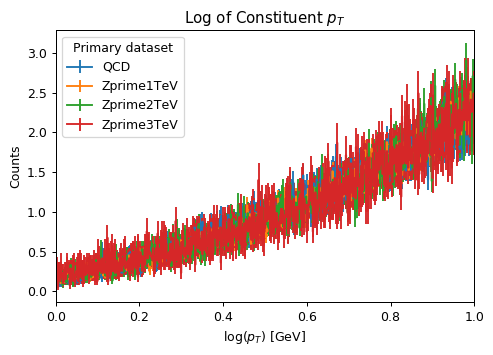

In [13]:
fig, ax = hist.plotgrid(output['h_log_pt_c'], overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'Log of Constituent $p_T$')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/logpt_c.png")

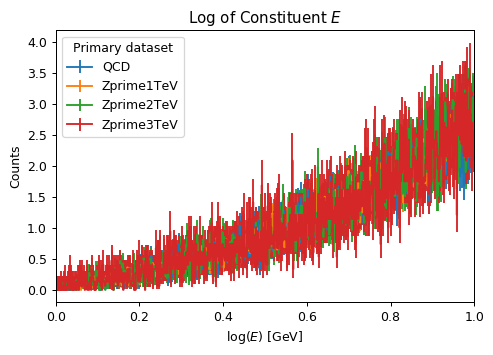

In [14]:
fig, ax = hist.plotgrid(output['h_log_E_c'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'Log of Constituent $E$')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/logE_c.png")

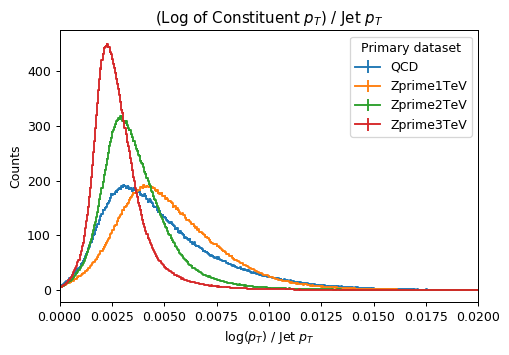

In [15]:
fig, ax = hist.plotgrid(output['h_log_pt_c_jetpt'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'(Log of Constituent $p_T$) / Jet $p_T$')
    iax.set_xlim([0,0.02])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/logpt_c_jetpt.png")

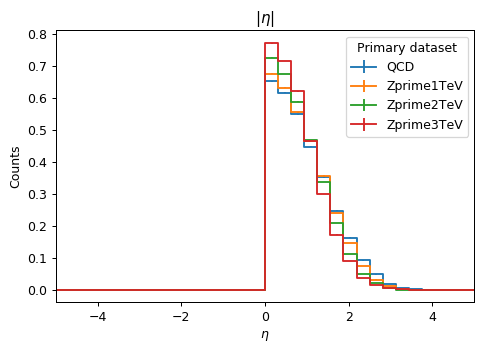

In [16]:
fig, ax = hist.plotgrid(output['h_eta_c'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'|$\eta$|')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/eta_c.png")

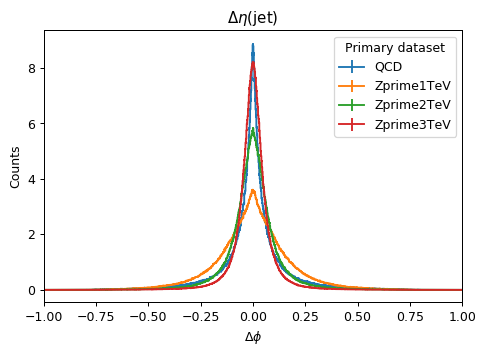

In [17]:
fig, ax = hist.plotgrid(output['h_deta_c_jet'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'$\Delta\eta$(jet)')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/deta_c_jet.png")

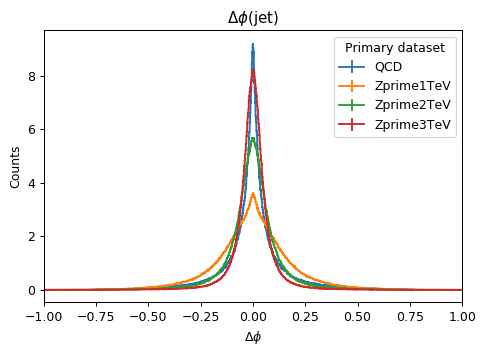

In [18]:
fig, ax = hist.plotgrid(output['h_dphi_c_jet'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'$\Delta\phi$(jet)')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/dphi_c_jet.png")

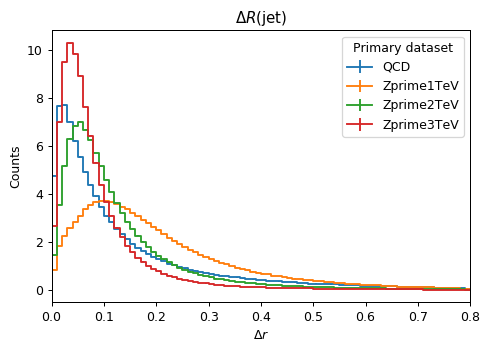

In [19]:
fig, ax = hist.plotgrid(output['h_dr_c_jet'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'$\Delta R$(jet)')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/dr_c_jet.png")

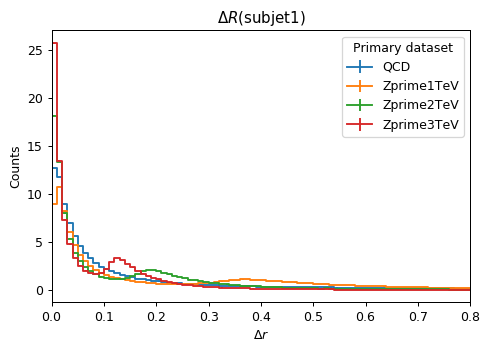

In [20]:
fig, ax = hist.plotgrid(output['h_dr_c_subjet1'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'$\Delta R$(subjet1)')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/dr_c_subjet1.png")

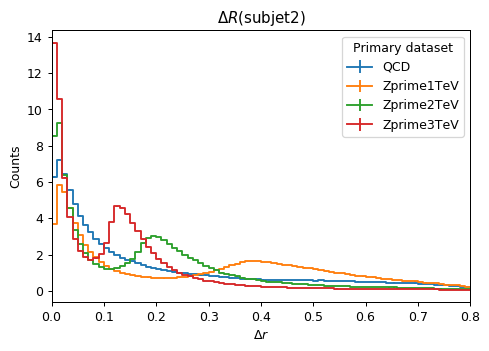

In [21]:
fig, ax = hist.plotgrid(output['h_dr_c_subjet2'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'$\Delta R$(subjet2)')
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/dr_c_subjet2.png")

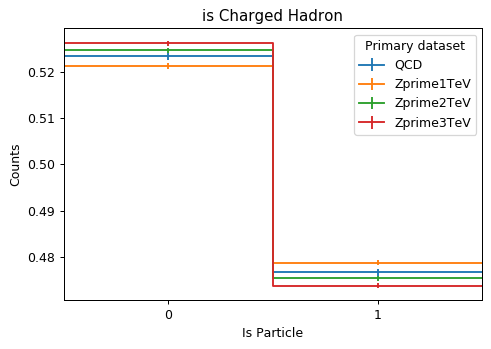

In [22]:
fig, ax = hist.plotgrid(output['h_particle'].integrate('particle','Charged Hadron'), overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Charged Hadron')
    iax.set_xticks([0,1])
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isCH.png")

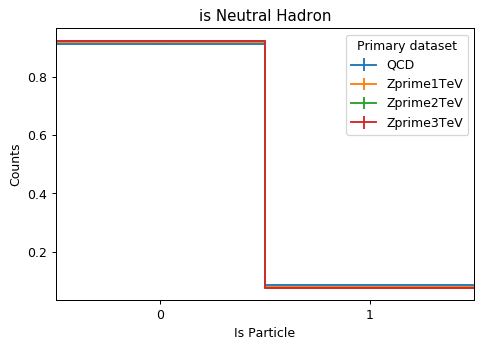

In [23]:
fig, ax = hist.plotgrid(output['h_particle'].integrate('particle','Neutral Hadron'), overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Neutral Hadron')
    iax.set_xticks([0,1])
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isNH.png")

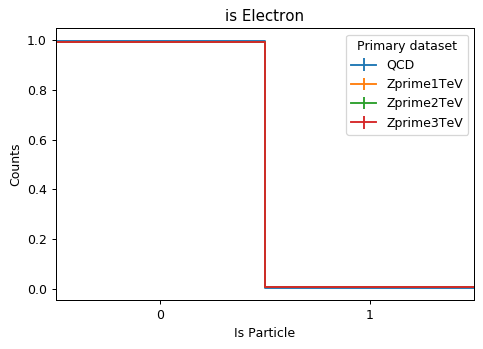

In [24]:
fig, ax = hist.plotgrid(output['h_particle'].integrate('particle','Electron'), overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Electron')
    iax.set_xticks([0,1])
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isEle.png")

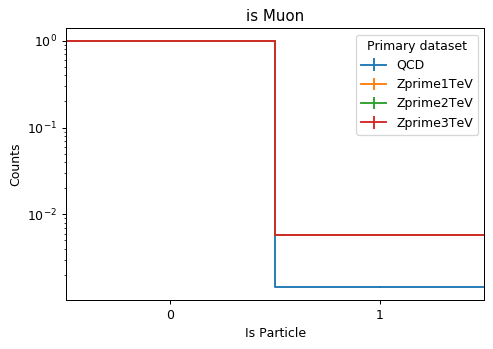

In [25]:
fig, ax = hist.plotgrid(output['h_particle'].integrate('particle','Muon'), overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Muon')
    iax.set_yscale('log')
    iax.set_xticks([0,1])
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isMuon.png")

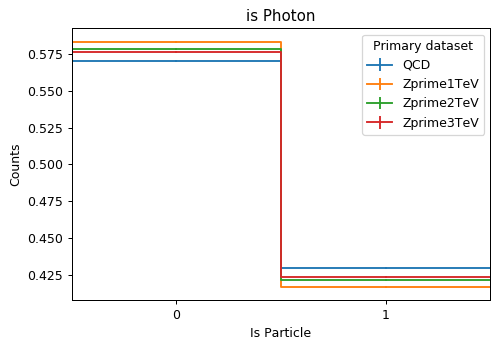

In [26]:
fig, ax = hist.plotgrid(output['h_particle'].integrate('particle','Photon'), overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Photon')
    iax.set_xticks([0,1])
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isPhoton.png")


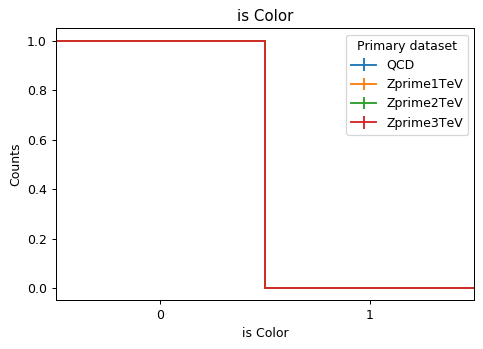

In [27]:
fig, ax = hist.plotgrid(output['h_color_c'], overlay="dataset", stack=False, density=True)

for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('is Color')
    iax.set_xlabel('is Color')
    iax.set_xticks([0,1])
    #iax.set_yscale('log')
    
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/isColor.png")

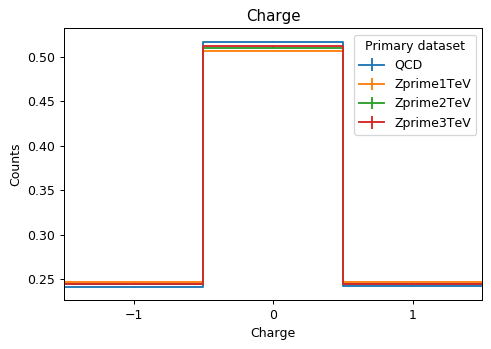

In [28]:
fig, ax = hist.plotgrid(output['h_charge_c'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'Charge')
    iax.set_xticks([-1,0,1])
    
    #iax.set_xlim([0,1750])
    #iax.set_ylim([1e-6,1])


fig.show()
fig.savefig("Variables/charge.png")

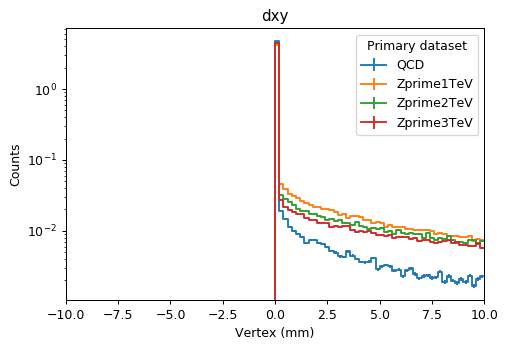

In [29]:
fig, ax = hist.plotgrid(output['h_dxy_c'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'dxy')
    iax.set_yscale('log')
    
    #iax.set_xlim([-1,1])
    #iax.set_ylim([1e-1,5e2])


fig.show()
fig.savefig("Variables/dxy.png")

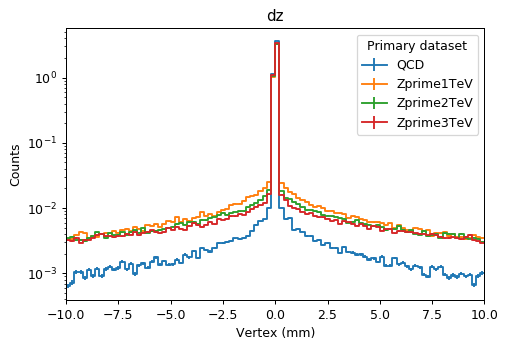

In [30]:
fig, ax = hist.plotgrid(output['h_dz_c'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title(r'dz')    
    iax.set_yscale('log')
    #iax.set_ylim([1e-1,5e2])


fig.show()
fig.savefig("Variables/dz.png")

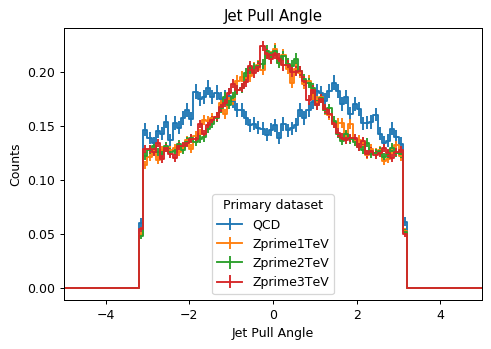

In [38]:
fig, ax = hist.plotgrid(output['h_jetPullAngle'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_title('Jet Pull Angle')
    #iax.set_xlim([0,3.142])
    #iax.set_ylim([-0.0,0.25])


fig.show()
fig.savefig("Variables/pullAngle.png")


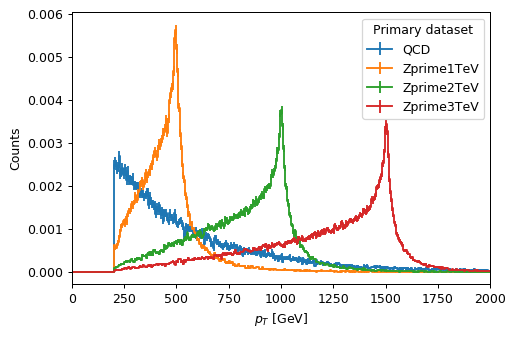

In [34]:
fig, ax = hist.plotgrid(output['h_jetpt'], overlay="dataset", stack=False, density=True
                                 )
for iax in ax.flatten():
    iax.autoscale(axis='y')
    iax.set_xlim([0,2000])


fig.show()
fig.savefig("Variables/jetpt.png")